In [1]:
from pathlib import Path

TRAIN_IMAGES = Path("../data/mesad/train/images")
VAL_IMAGES = Path("../data/mesad/val/images")

image_files = (
    list(TRAIN_IMAGES.rglob("*.jpg")) +
    list(TRAIN_IMAGES.rglob("*.png")) +
    list(VAL_IMAGES.rglob("*.jpg")) +
    list(VAL_IMAGES.rglob("*.png"))
)

print("Total Images:", len(image_files))

Total Images: 25390


In [2]:
TRAIN_ANN = Path("../data/mesad/train/annotations")
VAL_ANN = Path("../data/mesad/val/annotations")

bbox_files = (
    list(TRAIN_ANN.rglob("*.bboxes.tsv")) +
    list(VAL_ANN.rglob("*.bboxes.tsv"))
)

print("BBox Files:", len(bbox_files))

BBox Files: 25390


In [3]:
def load_mesad_annotation(bbox_path):

    label_path = str(bbox_path).replace(
        ".bboxes.tsv",
        ".bboxes.labels.tsv"
    )

    boxes = []
    labels = []

    with open(bbox_path, "r") as f:

        for line in f:

            xmin, ymin, xmax, ymax = map(
                int,
                line.strip().split()
            )

            boxes.append(
                [xmin, ymin, xmax, ymax]
            )

    with open(label_path, "r") as f:

        for line in f:
            labels.append(line.strip())

    return boxes, labels

In [4]:
import cv2
import matplotlib.pyplot as plt

image_path = next(TRAIN_IMAGES.rglob("*490*"))

print(image_path)

..\data\mesad\train\images\real1_frame_1490.jpg


In [9]:
print(next(TRAIN_IMAGES.rglob("*1490*")))

..\data\mesad\train\images\real1_frame_1490.jpg


In [10]:
print(next(TRAIN_ANN.rglob("*1490*.bboxes.tsv")))

..\data\mesad\train\annotations\real1_frame_1490.bboxes.tsv


In [11]:
bbox_path = next(TRAIN_ANN.rglob("*1490*.bboxes.tsv"))

boxes, labels = load_mesad_annotation(bbox_path)

print(boxes)
print(labels)

[[235, 353, 486, 560]]
['PullingSeminalVesicle']


In [13]:
bbox_path = next(TRAIN_ANN.rglob("*1490*.bboxes.tsv"))

boxes, labels = load_mesad_annotation(bbox_path)

print("Boxes:", boxes[:5])
print("Labels:", labels[:5])
print("Num boxes:", len(boxes))
print("Num labels:", len(labels))

Boxes: [[235, 353, 486, 560]]
Labels: ['PullingSeminalVesicle']
Num boxes: 1
Num labels: 1


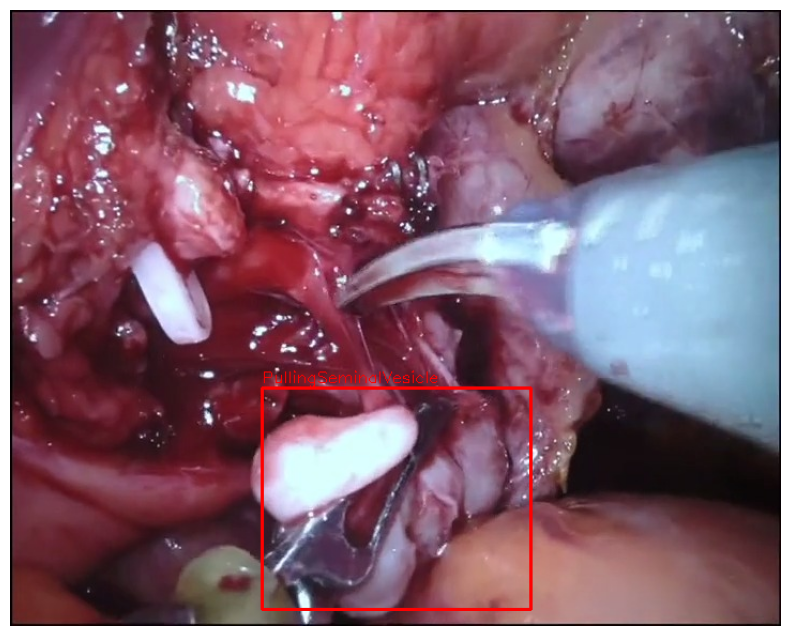

In [12]:
image_path = next(TRAIN_IMAGES.rglob("*1490*"))

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

for box, label in zip(boxes, labels):

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image,
        label,
        (xmin, ymin - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [15]:
import pandas as pd

In [16]:
from collections import Counter

class_counter = Counter()

all_label_files = (
    list(TRAIN_ANN.rglob("*.labels.tsv")) +
    list(VAL_ANN.rglob("*.labels.tsv"))
)

for label_file in all_label_files:

    with open(label_file, "r") as f:

        for line in f:

            label = line.strip()

            if label:
                class_counter[label] += 1

stats_df = pd.DataFrame(
    class_counter.items(),
    columns=["Class", "Count"]
)

stats_df = stats_df.sort_values(
    by="Count",
    ascending=False
)

stats_df

,Class,Count
4,PullingTissue,7761
0,CuttingTissue,6204
5,SuckingBlood,4894
20,BladderAnastomosis,4509
1,PullingSeminalVesicle,3194
2,CuttingSeminalVesicle,2811
16,BladderNeckDissection,2070
12,CuttingProstate,1914
13,PullingProstate,1120
3,SuckingSmoke,861


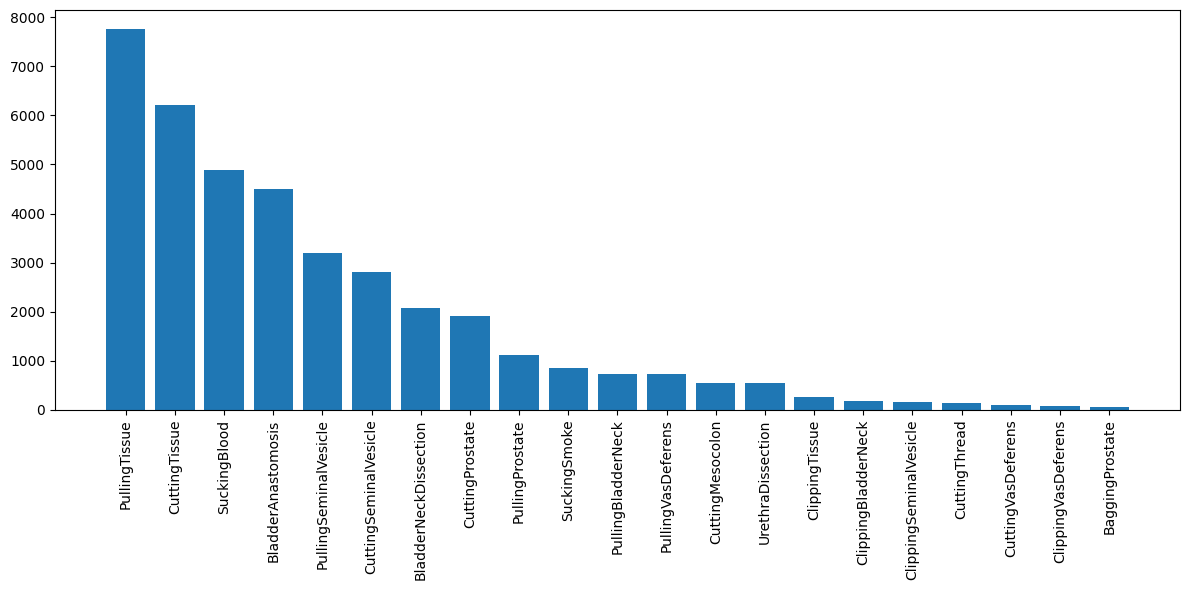

In [17]:
plt.figure(figsize=(12,6))

plt.bar(
    stats_df["Class"],
    stats_df["Count"]
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [19]:
import numpy as np

In [20]:
areas = []

bbox_files = (
    list(TRAIN_ANN.rglob("*.bboxes.tsv")) +
    list(VAL_ANN.rglob("*.bboxes.tsv"))
)

for bbox_file in bbox_files:

    boxes, labels = load_mesad_annotation(
        bbox_file
    )

    for xmin, ymin, xmax, ymax in boxes:

        width = xmax - xmin
        height = ymax - ymin

        areas.append(width * height)

print("Min Area:", min(areas))
print("Max Area:", max(areas))
print("Mean Area:", np.mean(areas))

Min Area: 3080
Max Area: 380712
Mean Area: 86634.32471907223


In [21]:
total_images = (
    len(list(TRAIN_IMAGES.rglob("*.jpg"))) +
    len(list(VAL_IMAGES.rglob("*.jpg")))
)

total_bbox_files = (
    len(list(TRAIN_ANN.rglob("*.bboxes.tsv"))) +
    len(list(VAL_ANN.rglob("*.bboxes.tsv")))
)

print("Total Images:", total_images)
print("Total Annotation Files:", total_bbox_files)

Total Images: 25390
Total Annotation Files: 25390
